In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from itertools import combinations
import pandas_datareader.data as web
import os
import re
import requests
import json
from datetime import datetime
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

In [2]:
# Read in the data of bonds and macro factors
data_bonds = pd.read_parquet('fred_prorcessed_daily_shifted.parquet')
data_bonds.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031,LNS14000006,UMCSENT,MICH,VMTD11,M1V,M2V,DEXVZUS,WEI,USAUCSFRCONDOSMSAMID
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,...,16.4,15.5,74.5,3.0,245054.0,8.434,1.741,4.2893,4.27,170709.114964
2011-01-02,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,...,16.8,15.8,74.2,3.4,246965.0,8.205,1.724,4.2893,3.60,169797.525129
2011-01-03,0.11,0.15,0.19,0.29,0.61,1.03,2.02,2.74,3.36,4.18,...,16.8,15.8,74.2,3.4,246965.0,8.205,1.724,4.2893,3.60,169797.525129
2011-01-04,0.12,0.14,0.19,0.28,0.63,1.04,2.01,2.72,3.36,4.21,...,16.8,15.8,74.2,3.4,246965.0,8.205,1.724,4.2893,3.60,169797.525129
2011-01-05,0.13,0.14,0.19,0.31,0.71,1.16,2.14,2.86,3.50,4.34,...,16.8,15.8,74.2,3.4,246965.0,8.205,1.724,4.2893,3.60,169797.525129


In [3]:
dependent_varaibles = [
    'DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30'
]

independent_variables = [col for col in data_bonds.columns if col not in dependent_varaibles]

# print the time period of the data
print("Time period of the data:", data_bonds.index.min(), "to", data_bonds.index.max())

Time period of the data: 2011-01-01 to 2023-12-31


In [64]:
# split the data into training and testing sets
df_train = data_bonds[data_bonds.index.to_timestamp() < pd.Timestamp('2020-01-01')]
df_test = data_bonds[data_bonds.index.to_timestamp() >= pd.Timestamp('2020-01-01')]

print("Training set time period:", df_train.index.min(), "to", df_train.index.max())
print("Testing set time period:", df_test.index.min(), "to", df_test.index.max())

Training set time period: 2011-01-01 to 2019-12-31
Testing set time period: 2020-01-01 to 2023-12-31


In [5]:
# How many dependent variables are there?
print("Number of dependent variables:", len(dependent_varaibles))

Number of dependent variables: 11


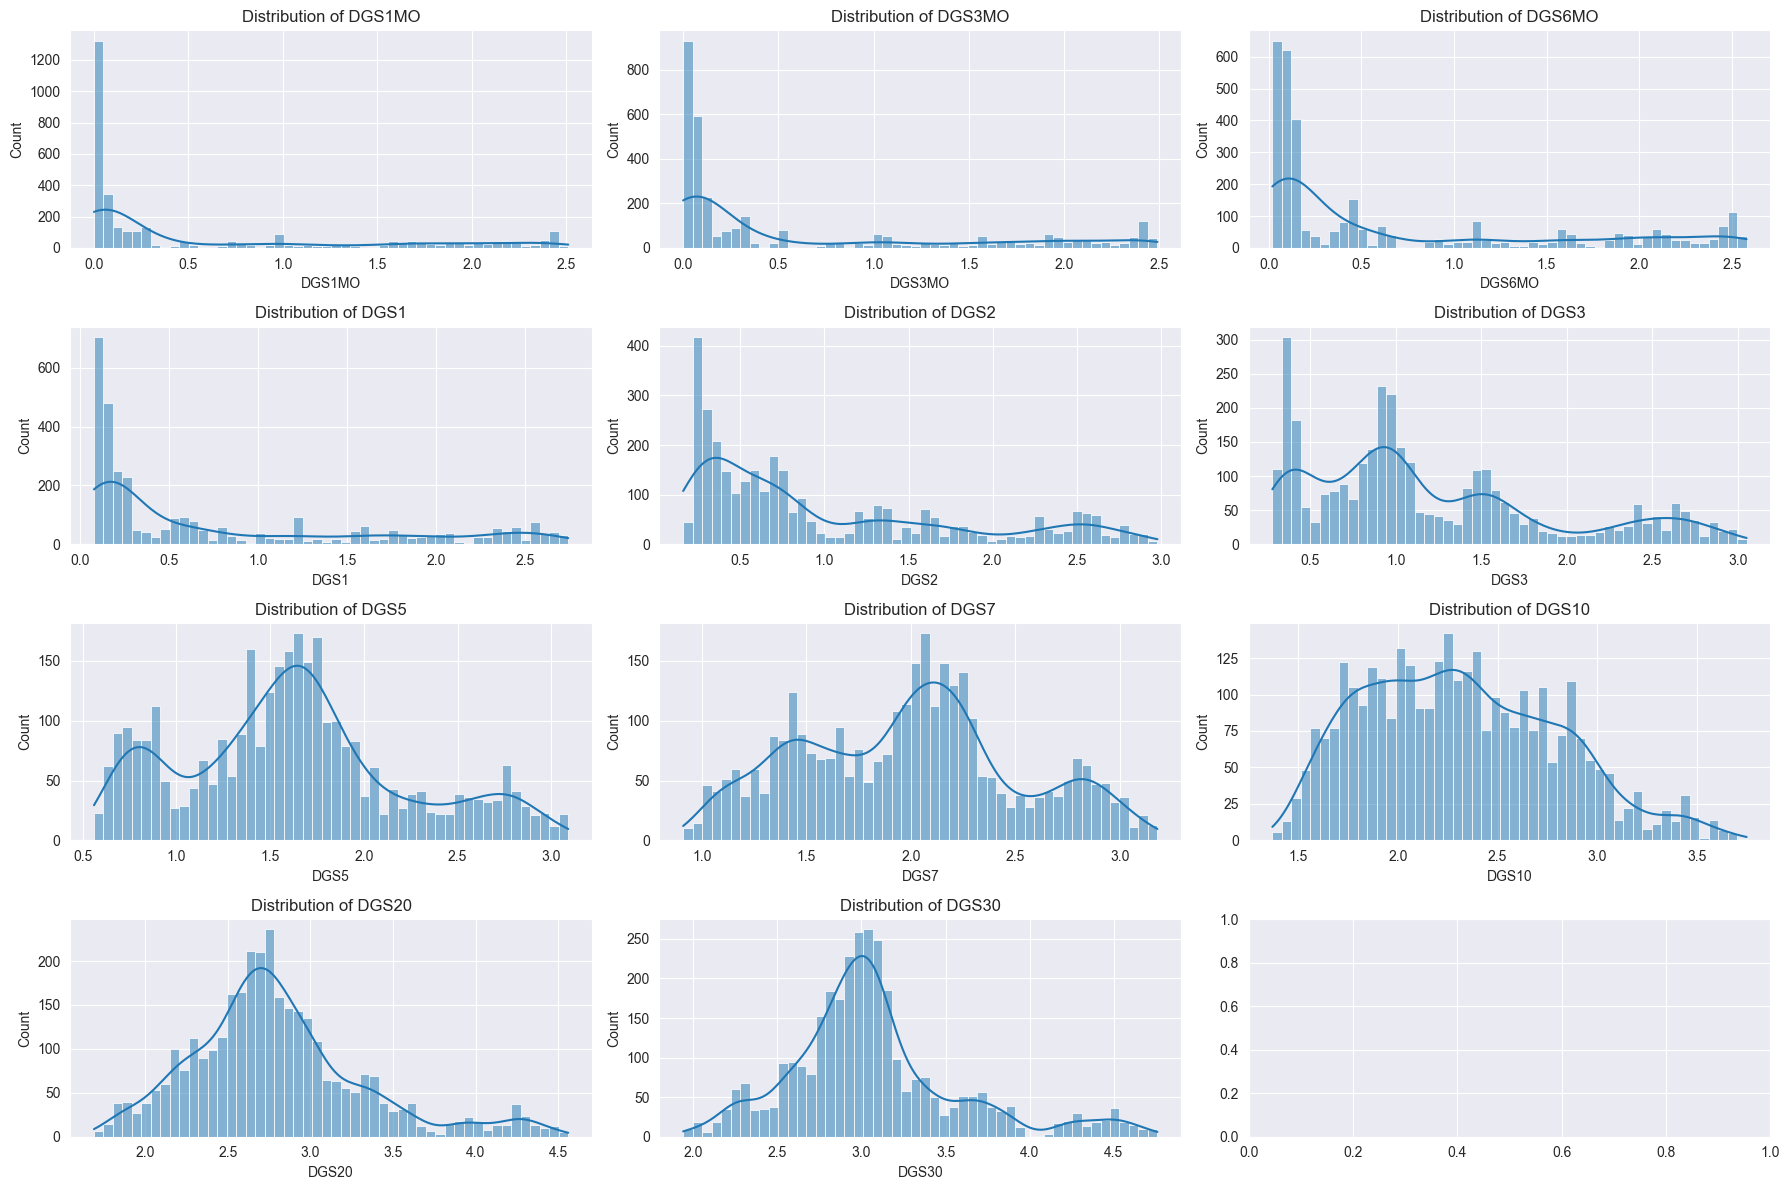

In [6]:
# Create a 6 by 6 subplot visulaizing the distribution of each dependent variable in data_bonds dataframe
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(dependent_varaibles):
    sns.histplot(df_train[col].dropna(), bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

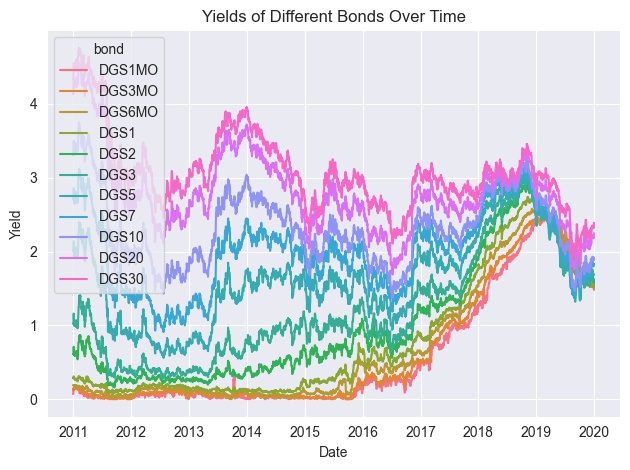

In [7]:
# melt a dataframe of the dependent variables to long format
df_train.index = df_train.index.to_timestamp()
df_melted = df_train[dependent_varaibles].reset_index().melt(id_vars='period', var_name='bond', value_name='yield')
# plot a line plot of the yields of each bond on the same graph using seaborn and the hue parameter
sns.lineplot(data=df_melted, x='period', y='yield', hue='bond')
plt.title('Yields of Different Bonds Over Time')
plt.xlabel('Date')
plt.ylabel('Yield')
plt.tight_layout()
plt.show()

In [8]:
df_melted.dtypes

period    datetime64[ns]
bond              object
yield            float64
dtype: object

In [9]:
# How many independent variables are there?
print("Number of independent variables:", len(independent_variables))

Number of independent variables: 483


In [11]:
# df_train2.describe()

In [18]:
# read in the data definitions
df_macro_info = pd.read_parquet('fred_series.parquet')
non_percent_cols = df_macro_info[(df_macro_info['id'].isin(independent_variables)) & (df_macro_info['units'] != 'Percent')]['id'].tolist()

df_train[non_percent_cols].describe()

fred_series = {
    'T5YIE': '5_Year_Inflation_Expectation',
    'T10YIE': '10_Year_Inflation_Expectation',
    'T10Y3M': '10_Year_3_Year_Spread',
    'FEDFUNDS': 'Fed_Funds_Rate',
    'THREEFYTP10': '10_Year_Term_Premium',
    'REAINTRATREARAT10Y': '10yr_real_intrest',
    # 'EFFR': 'Effective_Fed_Funds_Rate_Daily',
    'CPILFESL': 'CPI_Core',
    'USEPUINDXD': 'Economic_Policy_Uncertainty_US',
    'GEPUCURRENT': 'Global_EPU_Index',
    'REAINTRATREARAT10Y': 'Real_10-Year_Yield',
    'DFII10': '10_Year_TIPS_Yield',
    'DGS10': '10_Year_Treasury_Yield',
    'DTWEXBGS': 'Dollar_Index',
    'DCOILWTICO': 'Crude_Oil_Price_WTI',
    'DGS2': '2_Year_Treasury_Yield',
    'DGS5': '5_Year_Treasury_Yield',
    'WTISPLC': 'WTI_Spot_price',
    'INDPRO': 'Industrial_Production',
    'IPMAN': 'Manufacturing_Production',
    'CBBTCUSD': 'Bitcoin_spot_price',
    'M2SL': 'Money_supply',
    'GVZCLS': 'Gold_Volatility_Index',
    'M14062USM027NNBR': 'Gold_Reserves_US',
    'TRESEGUSM052N': 'Gold_Reserves_World',
    'SP500': 'S&P500_Index',
    'U2RATE': 'Unemployment_Rate_US',
    'FDHBFRBN': 'Federal_Debt_Hold_by_Fed',
    'T10Y2Y': '10yr_2yr_spread',
    'T10YIE': '10_year_breakeven_inflation',
    'T5YFF': '5_year_treasury_fed_funds',
    'TB3SMFFM': '3yr_t_bill_spread',
    'MORTGAGE30US': '30yr_mortgage_rate',
    'MORTGAGE15US': '15yr_mortgage_rate',
    'OBMMIFHA30YF': '30yr_fixed_fha',
    'TB3MS': '3mth_treasury',
    'EXUSEU': 'us_euro_exchange_rate',
    'EXJPUS': 'japan_usd_exchange_rate',
    'EXCHUS': 'china_usd_exchange_rate',
    'EXCAUS': 'canada_usd_exchange_rate',
    'EXUSUK': 'uk_usd_exchange_rate',
    'EXKOUS': 'skorea_usd_exchange_rate',
    'EXBZUS': 'brazil_usd_exchange_rate',
    'EXMXUS': 'mex_usd_exchange_rate',
    'EXINUS': 'india_usd_exchange_rate',
    'EXUSAL': 'aus_usd_exchange_rate',
    'EXSDUS': 'swd_usd_exchange_rate',
    'EXSGUS': 'sweden_usd_exchange_rate',
    'EXSIUS': 'singapore_usd_exchange_rate',
    'EXSFUS': 'safrice_usd_exchange_rate',
    'DTWEXBGS': 'us_dollar_index',
    'RTWEXBGS': 'broad_dollar_index',
    'SWPT': 'cc_bank_liquidity_swps',
    'WRESBAL': 'liabilities_reserve_bank',
    'BORROW': 'total_borrowing',
    'TOTRESNS': 'reserves_deposit_institutions',
    'ADPWINDINFONERSA': 'employement_information',
    'ADPWINDPROBUSNERSA': 'unemployment_business',
    'TENEXPCHAREARISPRE': 'real_risk_premium',
    'STLPPM': 'price_pressure',
    'TENEXPCHAINFRISPRE': 'inflation_risk_premium',
    'IR': 'import_price_index',
    'IR14270': 'import_price_index_non_money',
    'IR10000': 'import_price_oil',
    'IQ12260': 'export_non_money',
    'IQ': 'export_price_index',
    'MVGFD027MNFRBDAL': 'market_val_fed_debt',
    'MTSMFBP133FMS': 'borrow_public',
}
#
cols = list(fred_series.keys())
print(f"Length of Terrill's Columns: {len(cols)}")
df_macro_info[df_macro_info['id'].isin(cols)].shape
# get the columns are not in independent_variables
not_in_independent_variables = [col for col in cols if col not in independent_variables]
print(f"Columns not in independent variables: {not_in_independent_variables}")

Length of Terrill's Columns: 64
Columns not in independent variables: ['FEDFUNDS', 'GEPUCURRENT', 'DGS10', 'DGS2', 'DGS5', 'CBBTCUSD', 'M2SL', 'GVZCLS', 'M14062USM027NNBR', 'TRESEGUSM052N', 'SP500', 'U2RATE', 'T5YFF', 'TB3SMFFM', 'OBMMIFHA30YF', 'TB3MS', 'EXUSEU', 'EXJPUS', 'EXCHUS', 'EXCAUS', 'EXUSUK', 'EXKOUS', 'EXBZUS', 'EXMXUS', 'EXINUS', 'EXUSAL', 'EXSDUS', 'EXSGUS', 'EXSIUS', 'EXSFUS', 'BORROW', 'ADPWINDINFONERSA', 'ADPWINDPROBUSNERSA', 'TENEXPCHAREARISPRE', 'STLPPM', 'TENEXPCHAINFRISPRE', 'IR', 'IR14270', 'IR10000', 'IQ12260', 'IQ', 'MVGFD027MNFRBDAL', 'MTSMFBP133FMS']


In [60]:
forex = [
    'EXUSEU', 'EXJPUS', 'EXCHUS', 'EXCAUS', 'EXUSUK', 'EXKOUS', 'EXBZUS', 'EXMXUS', 'EXINUS', 'EXUSAL', 'EXSDUS', 'EXSGUS', 'EXSIUS', 'EXSFUS'
]

# # get the fred series for the forex columns
start = datetime(1950, 1, 1)
end = datetime(2025, 9, 25)
data = {}
for symbol in forex:
    try:
        data[symbol] = web.DataReader(symbol, 'fred', start, end)
    except Exception as e:
        print(f"Failed to fetch ({symbol})")

# concat the dataframs in the data dictionary into a single dataframe horizontally
df_forex = pd.concat(data.values(), axis=1)
df_forex.head()


Failed to fetch (EXSGUS)


,EXUSEU,EXJPUS,EXCHUS,EXCAUS,EXUSUK,EXKOUS,EXBZUS,EXMXUS,EXINUS,EXUSAL,EXSDUS,EXSIUS,EXSFUS
DATE,,,,,,,,,,,,,
1971-01-01,NaN,358.0200,NaN,1.0118,2.4058,NaN,NaN,NaN,NaN,1.1181,5.1639,NaN,0.7153
1971-02-01,NaN,357.5450,NaN,1.0075,2.4178,NaN,NaN,NaN,NaN,1.1238,5.1726,NaN,0.7117
1971-03-01,NaN,357.5187,NaN,1.0064,2.4187,NaN,NaN,NaN,NaN,1.1243,5.1628,NaN,0.7114
1971-04-01,NaN,357.5032,NaN,1.0077,2.4179,NaN,NaN,NaN,NaN,1.1238,5.1630,NaN,0.7117
1971-05-01,NaN,357.4130,NaN,1.0087,2.4187,NaN,NaN,NaN,NaN,1.1243,5.1660,NaN,0.7114


In [62]:
df_forex.tail()

,EXUSEU,EXJPUS,EXCHUS,EXCAUS,EXUSUK,EXKOUS,EXBZUS,EXMXUS,EXINUS,EXUSAL,EXSDUS,EXSIUS,EXSFUS
DATE,,,,,,,,,,,,,
2025-04-01,1.1232,144.1286,7.2968,1.3981,1.3144,1439.7777,5.7905,20.0387,85.5768,0.6291,9.7684,1.3231,18.9124
2025-05-01,1.1274,144.8762,7.2166,1.3867,1.3358,1391.4376,5.6664,19.4573,85.2462,0.6435,9.6631,1.2946,18.1222
2025-06-01,1.1534,144.4835,7.1804,1.3668,1.3577,1364.6775,5.5458,19.0203,85.8765,0.6509,9.5482,1.2825,17.8198
2025-07-01,1.1671,147.2014,7.1741,1.3691,1.3489,1379.2959,5.5332,18.6886,86.1714,0.6536,9.5975,1.2817,17.7702
2025-08-01,1.1647,147.4786,7.1727,1.3797,1.3456,1388.9990,5.4455,18.7063,87.5695,0.6495,9.5774,1.2847,17.6957


In [30]:
# filter data to the time period of df_train
df_forex.isna().sum() / df_forex.shape[0]

EXUSEU    0.0
EXJPUS    0.0
EXCHUS    0.0
EXCAUS    0.0
EXUSUK    0.0
EXKOUS    0.0
EXBZUS    0.0
EXMXUS    0.0
EXINUS    0.0
EXUSAL    0.0
EXSDUS    0.0
EXSIUS    0.0
EXSFUS    0.0
dtype: float64

In [31]:
df_forex.describe()

,EXUSEU,EXJPUS,EXCHUS,EXCAUS,EXUSUK,EXKOUS,EXBZUS,EXMXUS,EXINUS,EXUSAL,EXSDUS,EXSIUS,EXSFUS
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,1.177255,113.388568,6.644886,1.240760,1.396355,1179.126893,3.793756,17.363165,68.526830,0.786391,8.597006,1.331530,13.699510
std,0.109493,20.854666,0.368380,0.138206,0.149258,105.196504,1.358191,3.099951,10.966191,0.133085,1.423810,0.054678,3.513821
min,0.985300,76.643000,6.050900,0.955300,1.132000,1018.744300,1.562500,11.654200,44.301000,0.621800,6.199000,1.208900,6.720900
25%,1.090975,103.330950,6.342275,1.109375,1.271125,1111.733900,2.384150,13.676600,62.123925,0.687925,7.116300,1.282300,10.980750
50%,1.135700,110.099150,6.582650,1.293450,1.341900,1142.221550,3.782150,18.532150,67.926300,0.740950,8.659650,1.346900,14.090850
75%,1.249000,122.733350,6.929425,1.342225,1.550975,1218.856100,5.148800,19.946000,75.670050,0.888700,9.640250,1.366825,16.678875
max,1.446000,157.860000,7.307100,1.438900,1.706600,1458.345200,6.101000,24.179800,87.569500,1.078100,11.111100,1.435800,19.032200


In [63]:
# merge df_forex with df_train and df_test
# # remove EXSGUS from forex list as it is all nulls
# forex.remove('EXSGUS')
# df_train['Date'] = df_train.index
# df_train['Date'] = df_train['Date'].dt.to_timestamp()
# df_test['Date'] = df_test.index
# df_test['Date'] = df_test['Date'].dt.to_timestamp()
# df_forex['Date'] = pd.to_datetime(df_forex.index)
# df_train = df_train.merge(df_forex, on='Date', how='left', suffixes=('', ''))
# df_test = df_test.merge(df_forex, on='Date', how='left', suffixes=('', ''))
# # get the null count for the merged columns in df_train and df_test
# print("Null count in df_train after merging forex data:")
# print(df_train[forex].isna().sum()/ df_train.shape[0])
# print("Null count in df_test after merging forex data:")
# print(df_test[forex].isna().sum() / df_test.shape[0])

In [59]:
df_train[~ df_train[forex].isna()][forex]

,EXUSEU,EXJPUS,EXCHUS,EXCAUS,EXUSUK,EXKOUS,EXBZUS,EXMXUS,EXINUS,EXUSAL,EXSDUS,EXSIUS,EXSFUS
0,1.3371,82.625,6.5964,0.9939,1.5782,1118.8675,1.6745,12.128,45.375,0.9962,6.6673,1.2863,6.9239
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3283,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
# create a function that will scale each column down so the max value is single digits
def scale_to_single_digits(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    Scale each column down so the max value is single digits
    """
    # iterate through each column
    for col in cols:
        max_val = df[col].max()
        if pd.isna(max_val) or max_val == 0:
            continue
        scale_factor = 10 ** (len(str(int(max_val))) - 1)
        df[col] = df[col] / scale_factor
        df[col].describe()
    return df

# data_bonds2 = scale_to_single_digits(df=data_bonds, cols=independent_variables)
# rem
df_train2 = scale_to_single_digits(df=df_train, cols=independent_variables)
df_test2 = scale_to_single_digits(df=df_test, cols=independent_variables)
df_train2


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_12063/616209901.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col] / scale_factor
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_12063/616209901.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col] / scale_factor
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_12063/616209901.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031,LNS14000006,UMCSENT,MICH,VMTD11,M1V,M2V,DEXVZUS,WEI,USAUCSFRCONDOSMSAMID
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,...,1.64,1.55,0.745,3.0,2.45054,8.434,1.741,0.000043,4.27,1.707091
2011-01-02,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,...,1.68,1.58,0.742,3.4,2.46965,8.205,1.724,0.000043,3.60,1.697975
2011-01-03,0.11,0.15,0.19,0.29,0.61,1.03,2.02,2.74,3.36,4.18,...,1.68,1.58,0.742,3.4,2.46965,8.205,1.724,0.000043,3.60,1.697975
2011-01-04,0.12,0.14,0.19,0.28,0.63,1.04,2.01,2.72,3.36,4.21,...,1.68,1.58,0.742,3.4,2.46965,8.205,1.724,0.000043,3.60,1.697975
2011-01-05,0.13,0.14,0.19,0.31,0.71,1.16,2.14,2.86,3.50,4.34,...,1.68,1.58,0.742,3.4,2.46965,8.205,1.724,0.000043,3.60,1.697975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27,1.56,1.57,1.59,1.51,1.59,1.60,1.68,1.80,1.88,2.18,...,0.58,0.60,0.993,2.3,2.69023,5.542,1.437,0.454393,2.02,2.520265
2019-12-28,1.56,1.57,1.59,1.51,1.59,1.60,1.68,1.80,1.88,2.18,...,0.58,0.60,0.993,2.3,2.69023,5.542,1.437,0.451442,2.02,2.520265
2019-12-29,1.56,1.57,1.59,1.51,1.59,1.60,1.68,1.80,1.88,2.18,...,0.58,0.60,0.993,2.3,2.69023,5.542,1.437,0.451442,2.02,2.520265


In [66]:
# detrend the dataset by taking the difference between the current value and the value 1 day ago
# create an empty dataframe with the same index as df_train2 and df_test2
df_train_diff = pd.DataFrame(index=df_train2.index)
df_test_diff = pd.DataFrame(index=df_test2.index)
for col in df_train2.columns:
    df_train_diff[f'{col}'] = df_train2[col] - df_train2[col].shift(1)
    df_test_diff[f'{col}'] = df_test2[col] - df_test2[col].shift(1)

df_test_diff.describe()

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_12063/2821272931.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train_diff[f'{col}'] = df_train2[col] - df_train2[col].shift(1)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_12063/2821272931.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_diff[f'{col}'] = df_test2[col] - df_test2[col].shift(1)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_12063/2821272931.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usua

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031,LNS14000006,UMCSENT,MICH,VMTD11,M1V,M2V,DEXVZUS,WEI,USAUCSFRCONDOSMSAMID
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1.460000e+03,1460.000000,1460.000000
mean,0.002822,0.002637,0.002507,0.002192,0.001815,0.001637,0.001473,0.001404,0.001342,0.001336,...,-0.000075,-0.000055,-0.000203,0.000548,0.000010,-0.002717,-0.000048,-3.182770e-05,0.000004,0.000744
std,0.058366,0.034150,0.033928,0.044714,0.054552,0.055913,0.056026,0.055637,0.053222,0.051141,...,0.028225,0.028304,0.009813,0.087614,0.026442,0.098121,0.007397,1.095079e-01,0.024354,0.005539
min,-0.710000,-0.230000,-0.360000,-0.600000,-0.570000,-0.430000,-0.320000,-0.310000,-0.300000,-0.260000,...,-0.170000,-0.150000,-0.173000,-1.400000,-0.591700,-3.727000,-0.262000,-4.133440e+00,-0.273000,-0.013060
25%,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,-0.010000,-0.020000,-0.020000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
75%,0.000000,0.010000,0.010000,0.010000,0.010000,0.010000,0.020000,0.020000,0.020000,0.020000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.429000e-07,0.000000,0.000000
max,1.060000,0.340000,0.270000,0.340000,0.340000,0.350000,0.310000,0.290000,0.290000,0.350000,...,0.940000,0.990000,0.084000,1.200000,0.371300,0.072000,0.049000,2.056320e-01,0.275000,0.064055


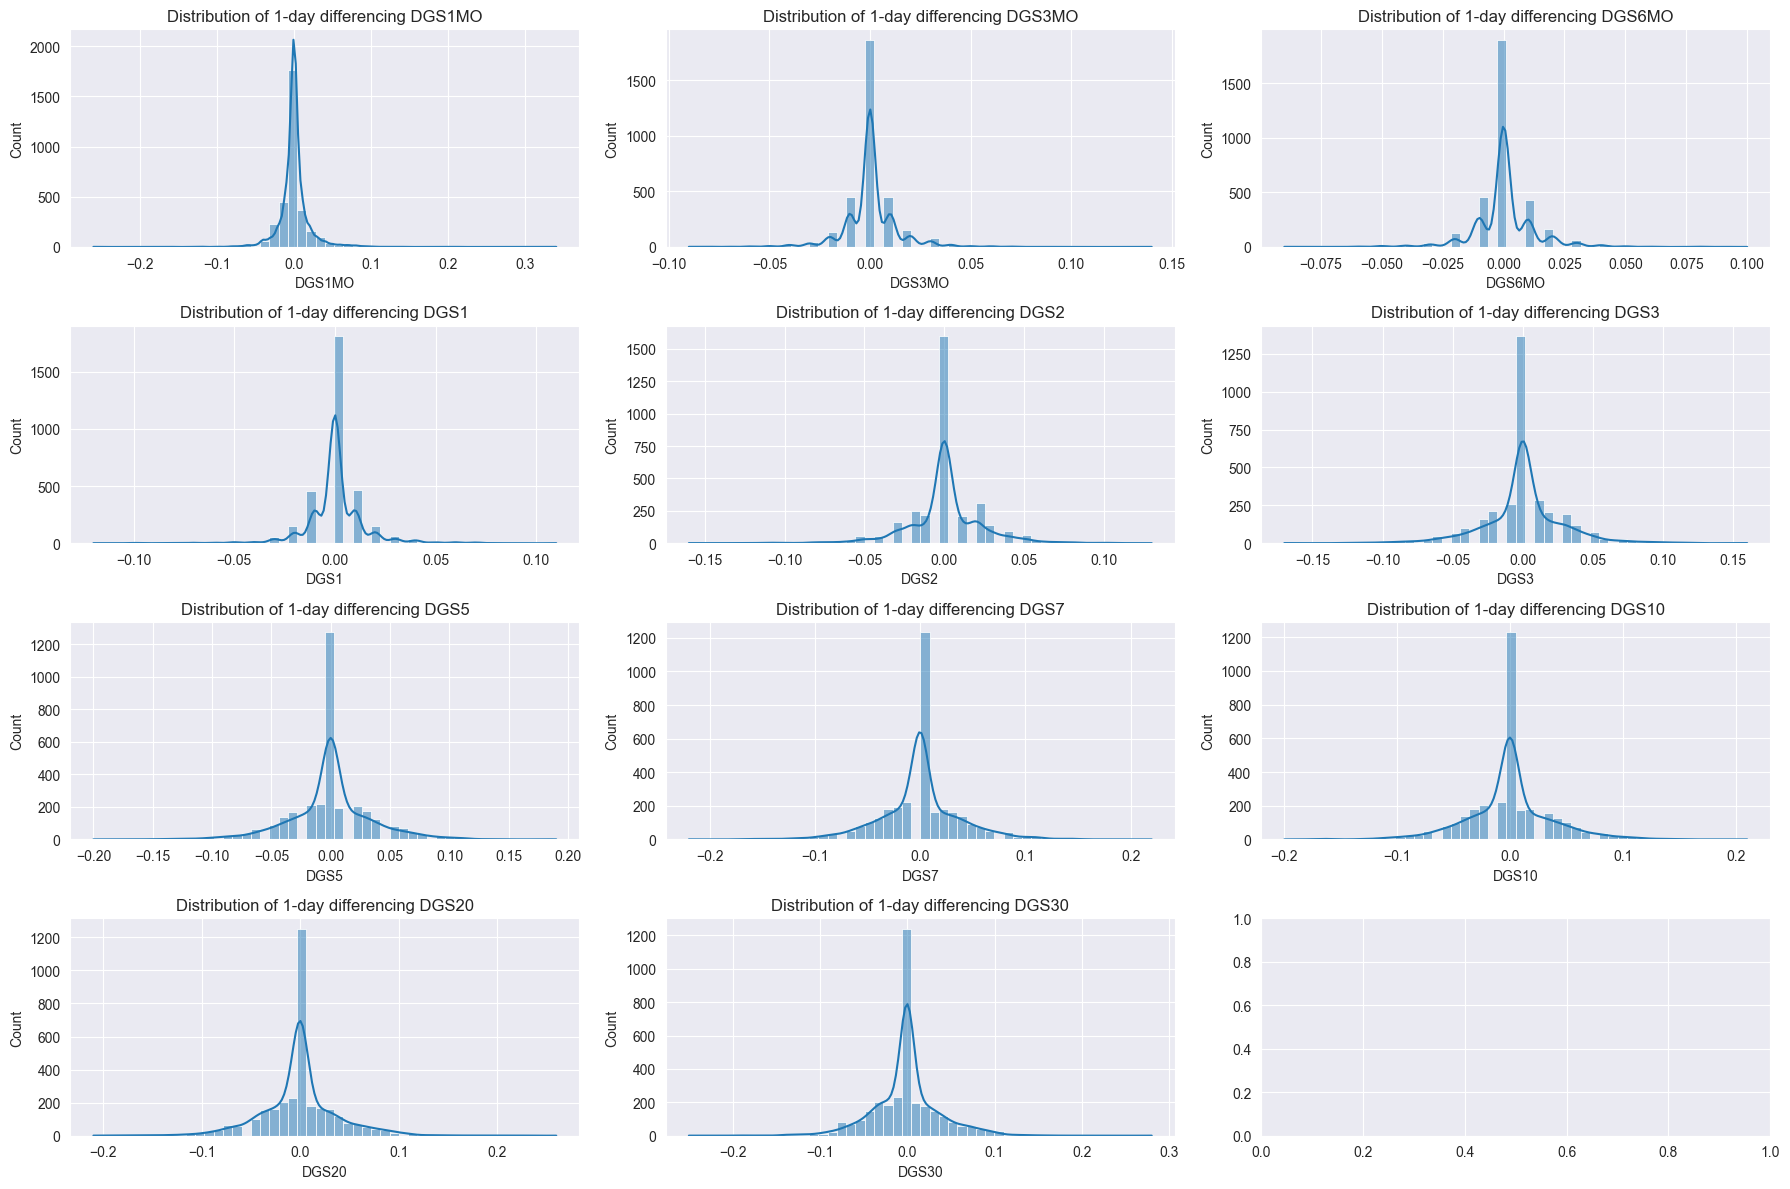

In [101]:
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(dependent_varaibles):
    sns.histplot(df_train_diff[col].dropna(), bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of 1-day differencing {col}')
plt.tight_layout()
plt.show()

In [73]:
df_train_diff.isna().sum() / df_train_diff.shape[0]

DGS1MO                  0.000304
DGS3MO                  0.000304
DGS6MO                  0.000304
DGS1                    0.000304
DGS2                    0.000304
                          ...   
M1V                     0.000304
M2V                     0.000304
DEXVZUS                 0.000304
WEI                     0.000304
USAUCSFRCONDOSMSAMID    0.000304
Length: 494, dtype: float64

In [95]:
# Check the stationarity for all variables in df_train_diff using adfuller and kpss tests
data_values = []
# iterate over the predictors
for variable in df_train_diff.columns:
    if variable == 'Date':
        continue
    try:
        # run the tests on the predictor
        adf_results = adfuller(df_train_diff[variable].dropna())
        kpss_results = kpss(df_train_diff[variable].dropna())
    except Exception as e:
        print(f"{variable} has infs or nans. Skipping.")
        continue
    # create the dataframe
    row_values = {
        'column': variable,
        'adf_statistic': adf_results[0],
        'adf_pvalue': adf_results[1],
        'kpss_statistic': kpss_results[0],
        'kpss_pvalue': kpss_results[1],
    }
    data_values.append(row_values)

df_variables = pd.DataFrame(data_values)
stationary_cols = df_variables[df_variables['adf_pvalue'] < 0.05]['column'].values
print(f"Number of stationary variables: {len(stationary_cols)} out of {df_variables.shape[0]}")

Number of stationary variables: 490 out of 490


In [76]:
# Create a dataframe to store the correlation results between each independent variable and each dependent variable
rows = []
counter = 0
for dependent_var in tqdm(dependent_varaibles):
    for independent_var in independent_variables:
        # get the correlation value between the two variables
        corr_val = df_train_diff[[dependent_var, independent_var]].corr()
        corr_val = corr_val.loc[dependent_var, independent_var]
        # print(f"Correlation between {dependent_var} and {independent_var}: {corr_val}")
        rows.append({
            'dependent_variable': dependent_var,
            'independent_variable': independent_var,
            'correlation': corr_val
        })

df_correlation = pd.DataFrame(rows)
# get the groupby count by dependent_variable
df_correlation_count = df_correlation['dependent_variable'].value_counts().reset_index()
df_correlation_count.columns = ['dependent_variable', 'count']
df_correlation_count = df_correlation_count.sort_values(by='count', ascending=False)
df_correlation_count.head(15)

100%|██████████| 11/11 [00:03<00:00,  3.45it/s]


,dependent_variable,count
0,DGS1MO,483
1,DGS3MO,483
2,DGS6MO,483
3,DGS1,483
4,DGS2,483
5,DGS3,483
6,DGS5,483
7,DGS7,483
8,DGS10,483
9,DGS20,483


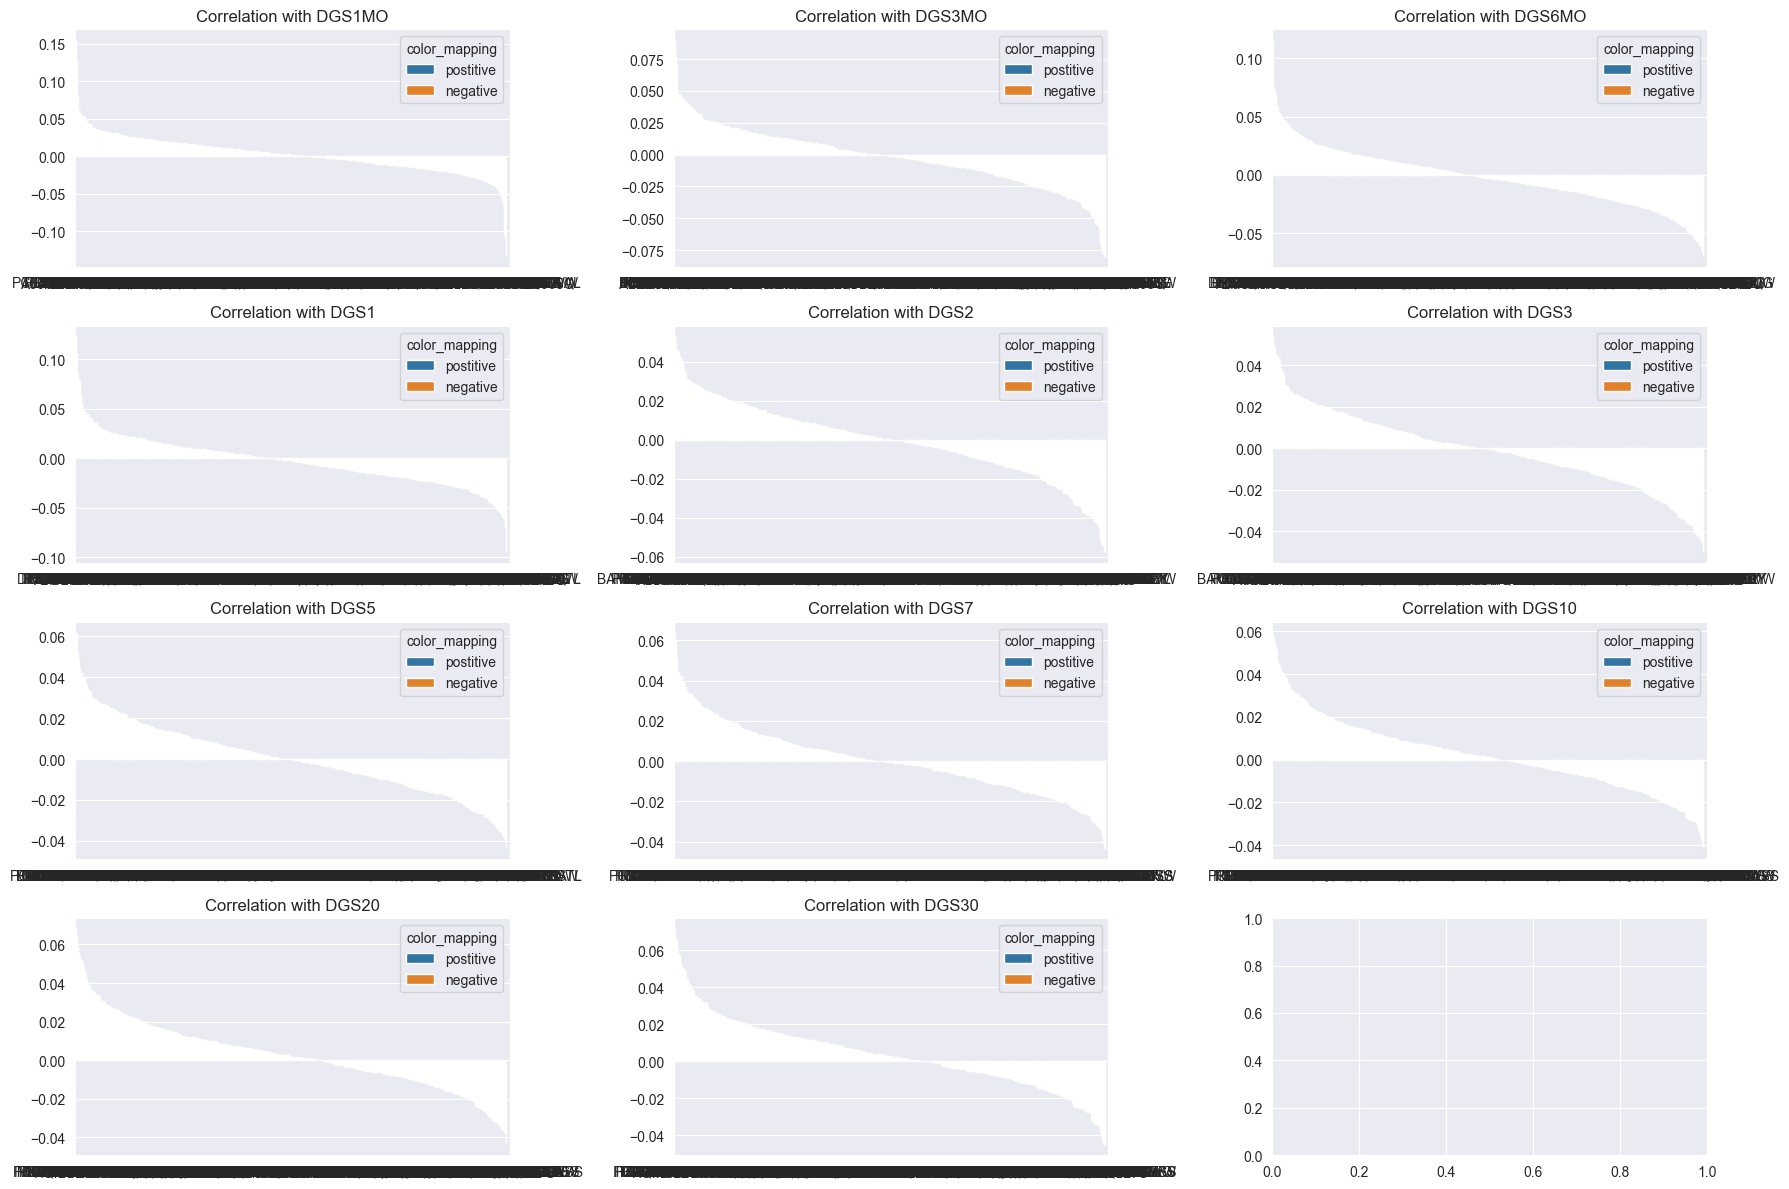

In [77]:
# Sort the correlation dataframe by correlation value in descending order
df_correlation_sorted = df_correlation.sort_values(by='correlation', ascending=False)
df_correlation_sorted['color_mapping'] = df_correlation_sorted['correlation'].apply(lambda x: 'postitive' if x > 0 else 'negative')
# Plot the correlation values using seaborn barplot. Remove x labels. Use green for correlations above 0 and red for those less than. Do this for each dependent variable by creating a 6 by 6 subplot

fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
for i, dependent_var in enumerate(dependent_varaibles):
    df_tmp = df_correlation_sorted[df_correlation_sorted['dependent_variable'] == dependent_var]
    sns.barplot(data=df_tmp, x='independent_variable', y='correlation', hue='color_mapping', ax=axes[i])
    axes[i].set_title(f'Correlation with {dependent_var}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
plt.tight_layout()

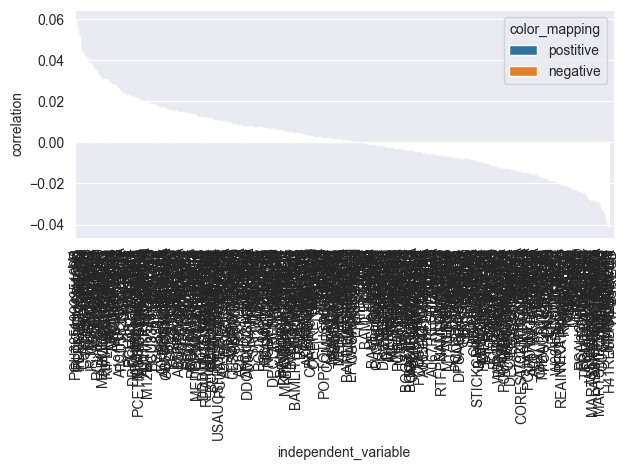

In [78]:
df_tmp = df_correlation_sorted[df_correlation_sorted['dependent_variable'] == 'DGS10']
sns.barplot(data=df_tmp, x='independent_variable', y='correlation', hue='color_mapping')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

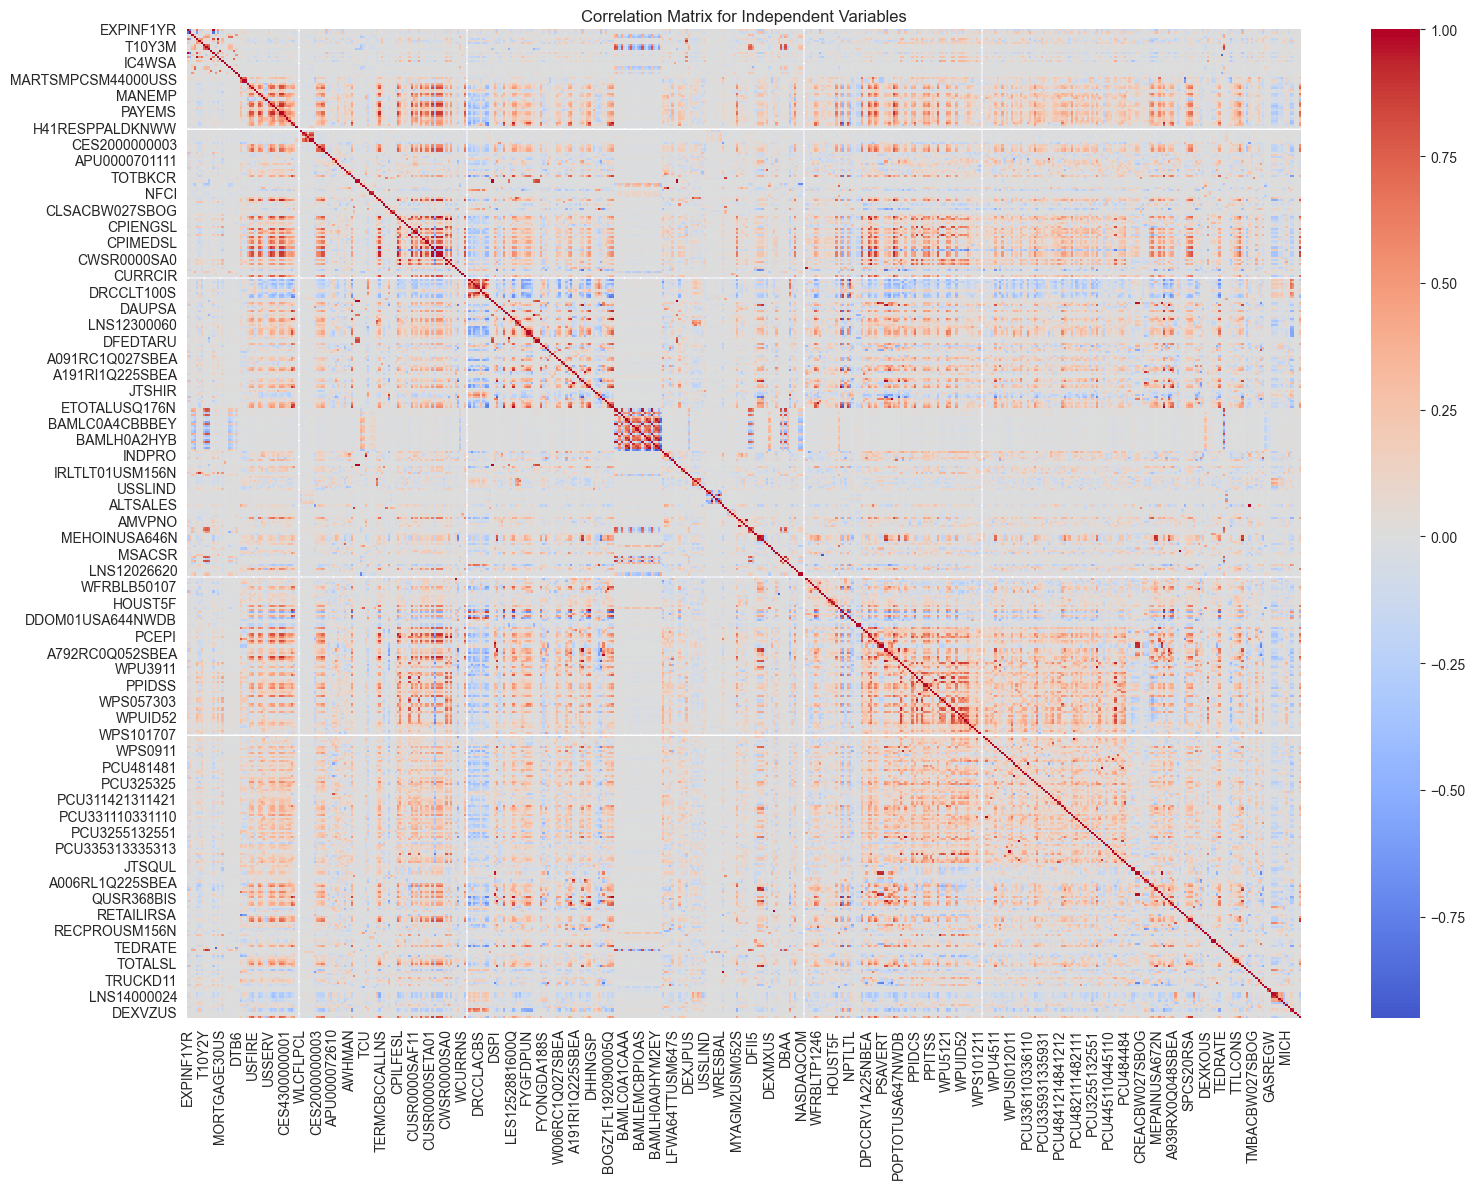

In [94]:
# get the values that are above 0.6 or below -0.6
# df_correlation_extreme = df_correlation_sorted[(df_correlation_sorted['correlation'] >= 0.6) | (df_correlation_sorted['correlation'] <= -0.6)]
#
# # For each depedent variable, plot the correlation matrix between the values that are above 0.6 or below -0.6
# fig, axes = plt.subplots(4, 3, figsize=(22, 20))
# axes = axes.flatten()
# for i, dependent_var in enumerate(dependent_varaibles):
#     df_tmp = df_correlation_extreme[df_correlation_extreme['dependent_variable'] == dependent_var]
#     corr_columns = df_tmp['independent_variable'].tolist() + [dependent_var]
#     df_corr_matrix = df_train[corr_columns].corr()
#     sns.heatmap(df_corr_matrix, fmt=".2f", cmap='coolwarm', center=0, ax=axes[i])
#     axes[i].set_title(f'Correlation Matrix for {dependent_var}')
# plt.tight_layout()

# plot the corelation matrix for the independent variables
plt.figure(figsize=(16, 12))
sns.heatmap(df_train_diff[independent_variables].corr(), fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Independent Variables')
plt.tight_layout()
plt.show()

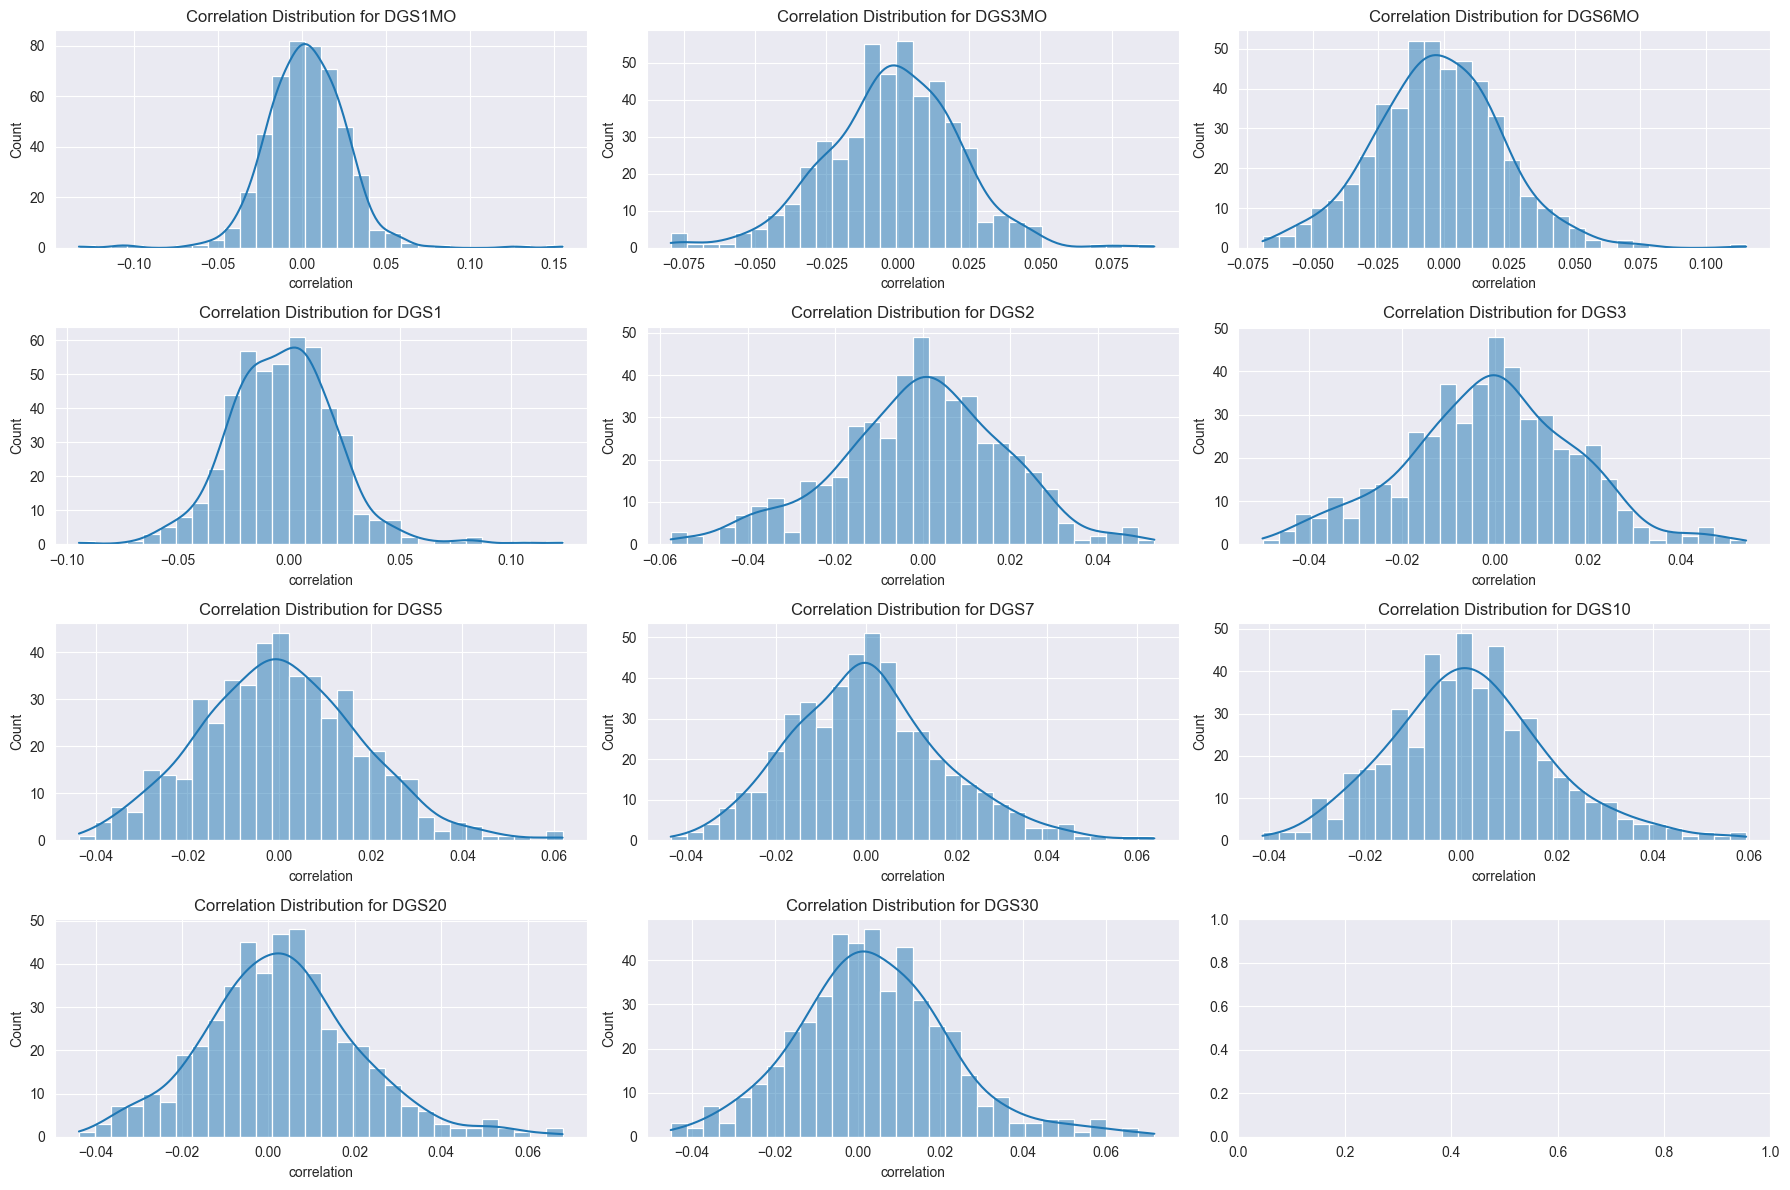

In [79]:
# plot the distribttion of correlations for each dependent variable using seaborn histplot in a 6 by 6 subplot
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
for i, dependent_var in enumerate(dependent_varaibles):
    df_tmp = df_correlation_sorted[df_correlation_sorted['dependent_variable'] == dependent_var]
    sns.histplot(data=df_tmp, x='correlation', bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Correlation Distribution for {dependent_var}')
plt.tight_layout()


In [96]:
# TO:DO run PCA once and pass all the dependent variables to the fit function and pass only the independent variables to the fit function
# # run PCA on the independent variables for each dependent variable
df_tmp = df_train_diff.dropna()
pca = PCA(n_components=0.95, svd_solver='full').fit(X=df_tmp[independent_variables])
# Capture the metrics and the transformed data
pca_vals = pca.transform(X=df_tmp[independent_variables])
pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
df_pca = pd.DataFrame(pca_vals, columns=pca_columns, index=df_tmp.index)
# add the dependent variable back to the dataframe
df_pca[dependent_varaibles] = df_tmp[dependent_varaibles].values


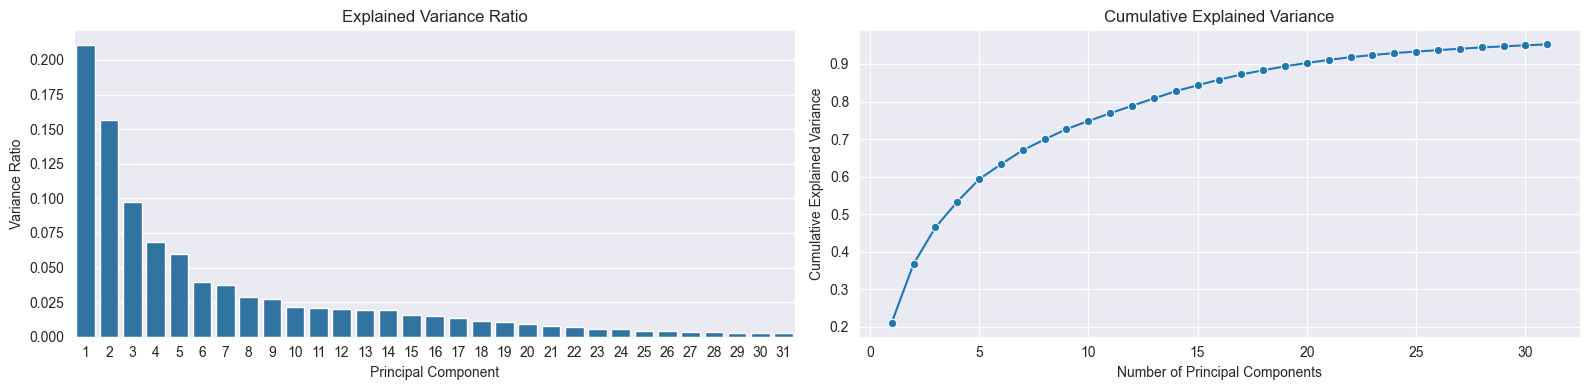

In [97]:
# for each dependent variable, plot the explained variance ratio and cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for i in range(2):
    if i == 0:
        sns.barplot(x=range(1, len(pca.explained_variance_ratio_)+1), y=pca.explained_variance_ratio_, ax=axes[i])
        axes[i].set_title('Explained Variance Ratio')
        axes[i].set_xlabel('Principal Component')
        axes[i].set_ylabel('Variance Ratio')
    else:
        cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
        sns.lineplot(x=range(1, len(cumulative_explained_variance)+1), y=cumulative_explained_variance, marker='o', ax=axes[i])
        axes[i].set_title('Cumulative Explained Variance')
        axes[i].set_xlabel('Number of Principal Components')
        axes[i].set_ylabel('Cumulative Explained Variance')
plt.tight_layout()


In [101]:
# get the combinations between pca_columns and dependent_varaibles
# combi = []
# for dependent_var in dependent_varaibles:
#     for pca_col in pca_columns:
#         combi.append((dependent_var, pca_col))

# plot the pairplot for the first 7 principal components and all dependent variables
# plot_cols = pca_columns[:7] + dependent_varaibles
# sns.pairplot(df_pca[plot_cols], kind='kde')
# independent_variables
# plot_cols = pca_columns[:4] + dependent_varaibles
# sns.pairplot(df_pca[plot_cols], kind='kde')

df_pca[plot_cols].describe()

,PC1,PC2,PC3,PC4,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
count,3.286000e+03,3.286000e+03,3.286000e+03,3.286000e+03,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000,3286.00000,3286.000000,3286.000000
mean,-5.608552e-18,-2.702917e-19,2.027188e-18,1.554177e-18,0.000429,0.000435,0.000429,0.000396,0.000295,0.000183,-0.000097,-0.000268,-0.00042,-0.000572,-0.000593
std,5.374286e-01,4.631630e-01,3.650879e-01,3.060382e-01,0.020962,0.013957,0.013148,0.015006,0.024433,0.029423,0.036207,0.039226,0.03851,0.039393,0.038859
min,-3.050681e+00,-9.032870e+00,-7.042852e+00,-5.692853e+00,-0.260000,-0.090000,-0.090000,-0.120000,-0.160000,-0.170000,-0.200000,-0.220000,-0.20000,-0.210000,-0.250000
25%,-2.841284e-01,-2.292360e-02,-8.905628e-04,-6.772101e-03,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.020000,-0.02000,-0.020000,-0.020000
50%,-2.352450e-03,2.237888e-04,2.579296e-04,-1.915374e-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,2.783386e-01,2.244098e-02,1.632916e-03,6.536817e-03,0.000000,0.000000,0.000000,0.000000,0.010000,0.010000,0.010000,0.020000,0.01000,0.010000,0.010000
max,3.463771e+00,1.333386e+01,7.864089e+00,6.079052e+00,0.340000,0.140000,0.100000,0.110000,0.130000,0.160000,0.190000,0.220000,0.21000,0.260000,0.280000


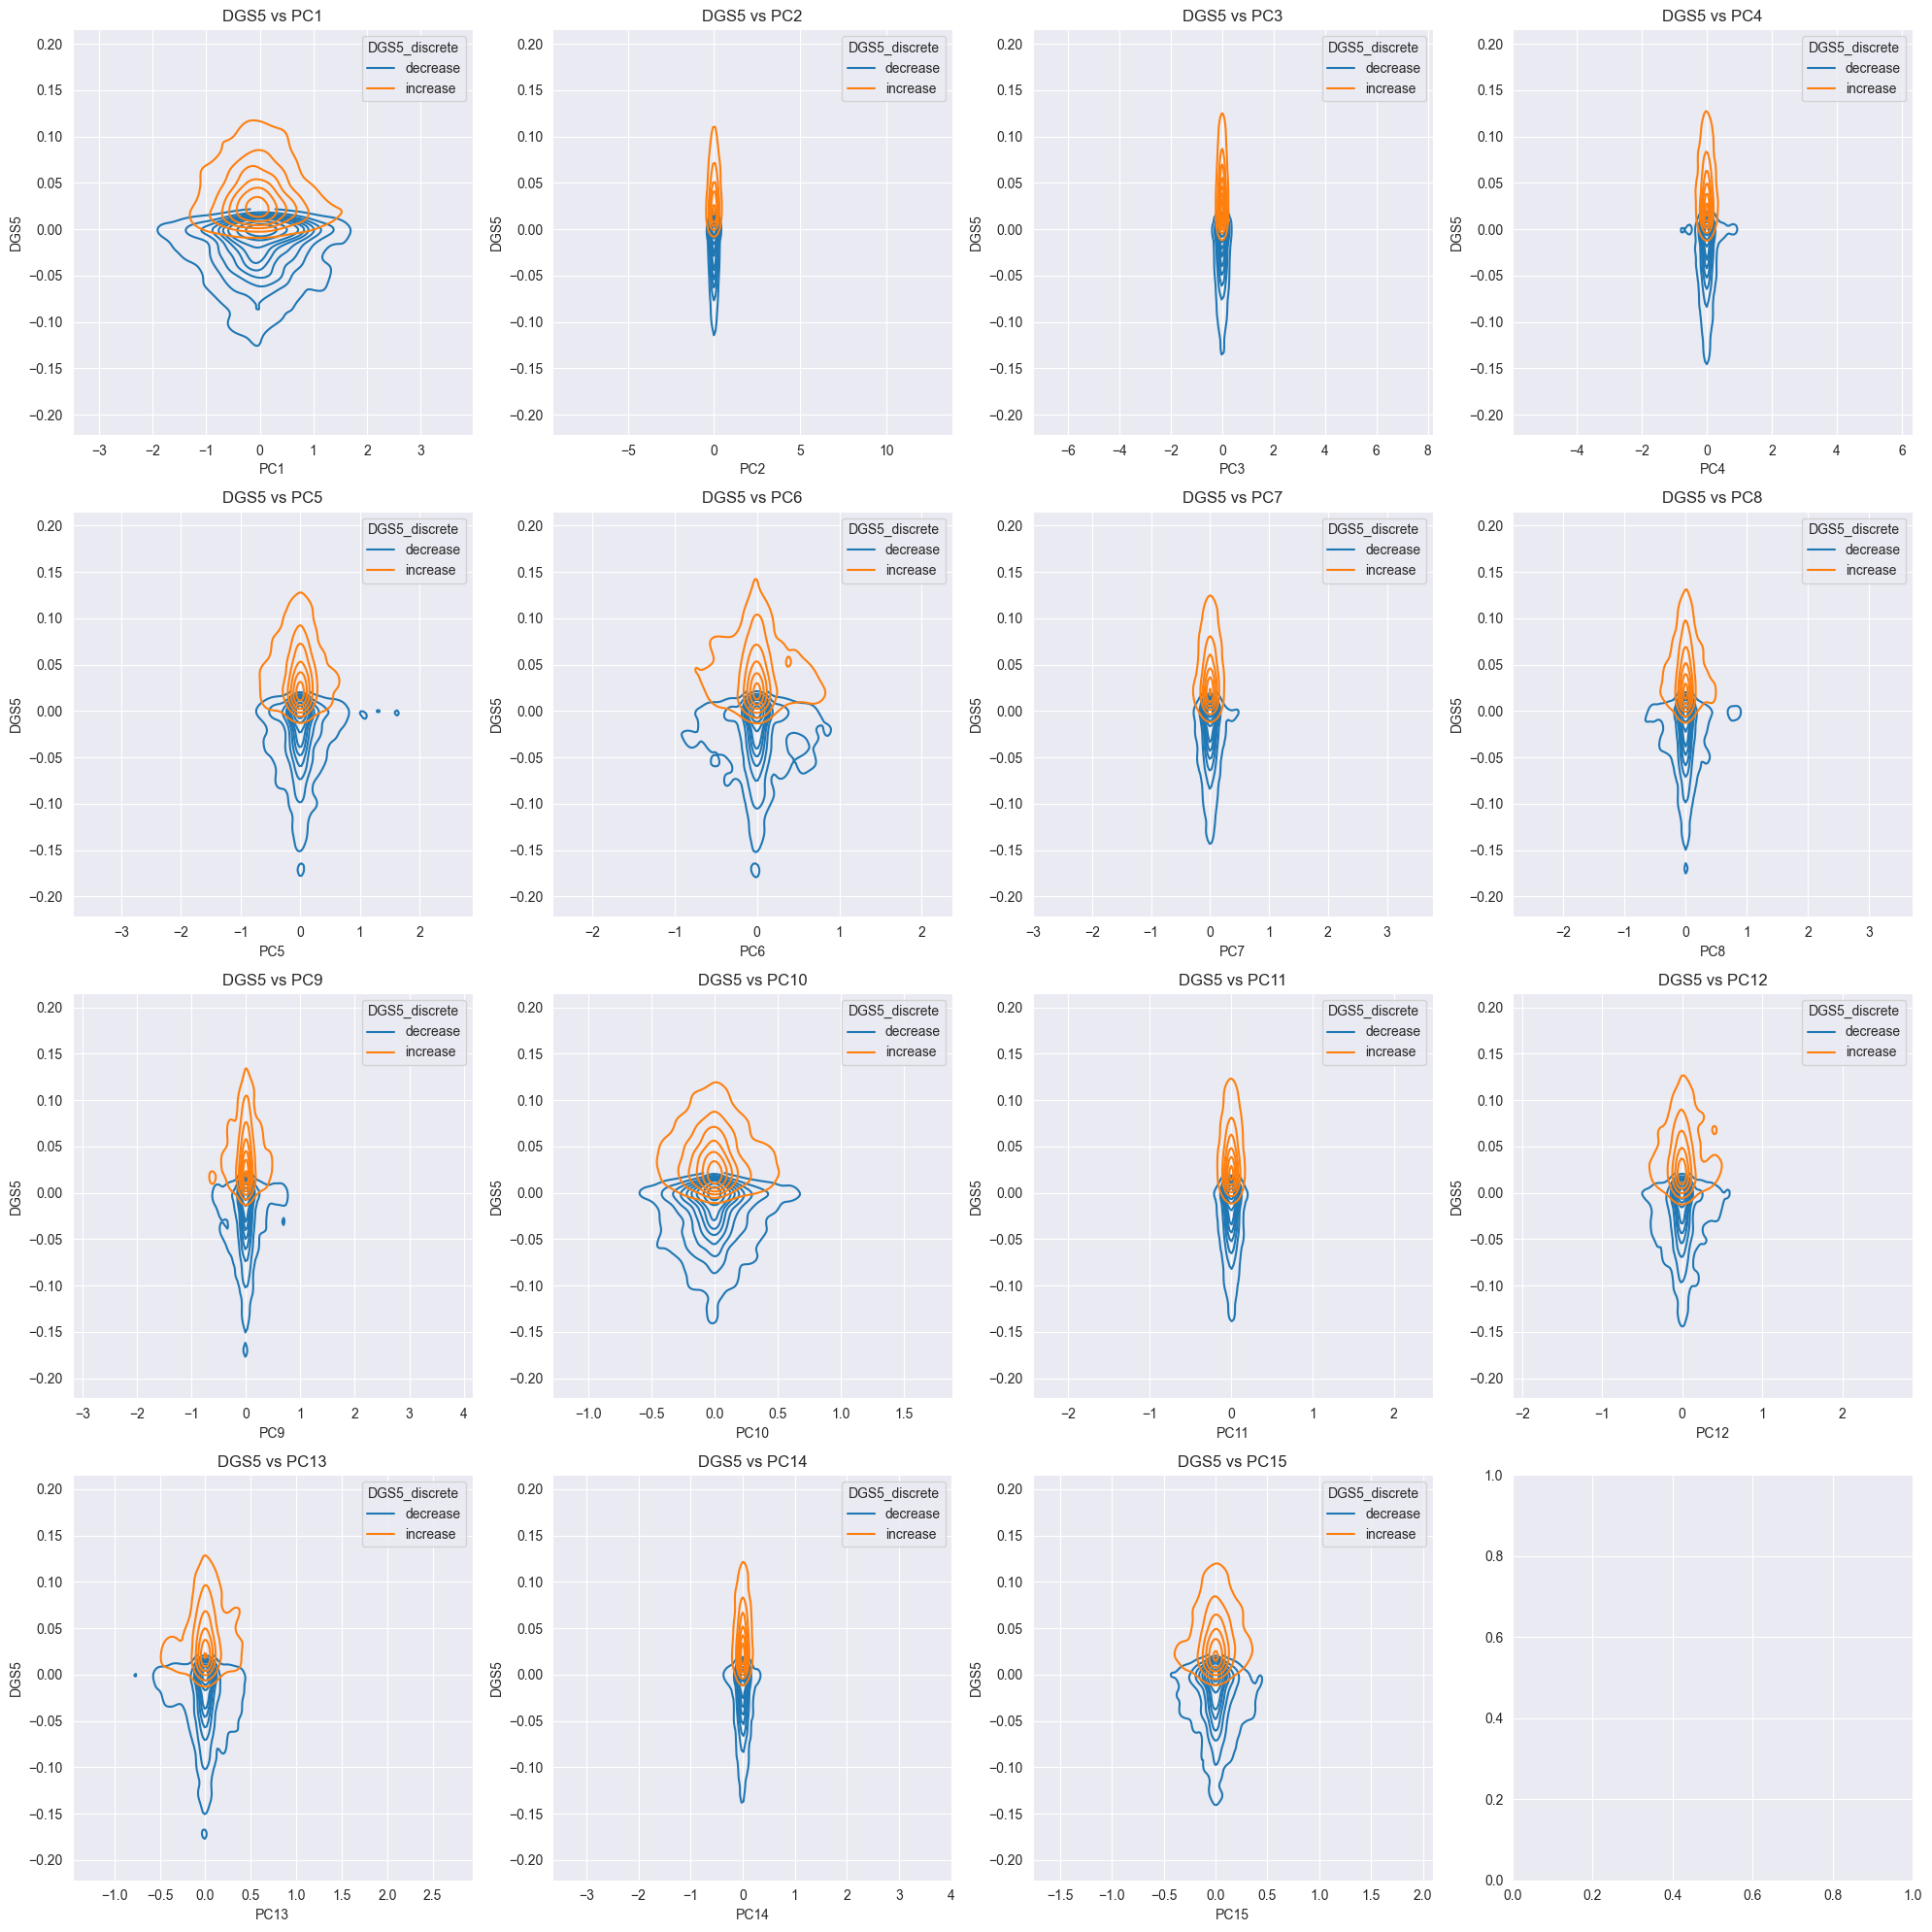

In [103]:
# create a discrete variable for each dependent variable based on whether the value is above or below 0
for dependent_var in dependent_varaibles:
    df_pca[f'{dependent_var}_discrete'] = df_pca[dependent_var].apply(lambda x: 'increase' if x > 0 else 'decrease')

# create 14 sublplots
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

# dependent_varaibles = [
#     'DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30'
# ]
dependent_var = 'DGS5'
# for each dependent variable, plot the scatter plot against each principal component
for i, pca_col in enumerate(pca_columns[:15]):
    sns.kdeplot(data=df_pca, x=pca_col, y=dependent_var, hue=f'{dependent_var}_discrete', ax=axes[i])
    axes[i].set_title(f'{dependent_var} vs {pca_col}')
plt.tight_layout()


In [115]:
df_train_diff

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031_diff,LNS14000006_diff,UMCSENT_diff,MICH_diff,VMTD11_diff,M1V_diff,M2V_diff,DEXVZUS_diff,WEI_diff,USAUCSFRCONDOSMSAMID_diff
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-03,0.04,0.03,0.00,0.00,0.00,0.01,0.01,0.03,0.06,0.05,...,-0.04,-0.03,0.003,-0.4,-0.01911,0.229,0.017,0.000000e+00,0.067,0.009116
2011-01-04,0.01,-0.01,0.00,-0.01,0.02,0.01,-0.01,-0.02,0.00,0.03,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,0.000000e+00,0.000,0.000000
2011-01-05,0.01,0.00,0.00,0.03,0.08,0.12,0.13,0.14,0.14,0.13,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,0.000000e+00,0.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27,-0.03,-0.01,-0.02,-0.02,-0.05,-0.05,-0.04,-0.05,-0.02,-0.01,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,-1.600000e-09,0.000,0.000000
2019-12-28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,-2.950924e-04,0.000,0.000000
2019-12-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,2.950940e-04,0.000,0.000000
